In [1]:
import csv
from io import StringIO
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Wczytanie i uporządkowanie danych

In [2]:
dane = "../data/codz_2024.csv"

### Wyczyszczenie pliku csv

In [3]:
cleaned = []
with(Path(dane).open("r", encoding="cp1250", newline="") as input_file):
    input_reader = csv.reader(input_file)
    
    for line in input_reader:
        cleaned_line = next(csv.reader(StringIO(line[0])))
        cleaned.append(cleaned_line)

In [4]:
columns = ["kod_stacji", "stacja", "rzeka", "rok_hydro", "miesiac_hydro", "dzien", "stan", "przeplyw", "temperatura", "miesiac"]
codz_2024 = pd.DataFrame(cleaned, columns=columns)

In [5]:
codz_2024["kod_rzeki"] = codz_2024["rzeka"].str.rsplit(" (", expand=True)[1].str.strip(")")
codz_2024["rzeka"] = codz_2024["rzeka"].str.rsplit(" (", expand=True)[0]

### Typy danych

In [6]:
cols_to_change = ["rok_hydro", "miesiac_hydro", "dzien", "miesiac", "stan", "przeplyw", "temperatura"]
codz_2024[cols_to_change] = codz_2024[cols_to_change].apply(pd.to_numeric, errors="coerce")

codz_2024.head()

,kod_stacji,stacja,rzeka,rok_hydro,miesiac_hydro,dzien,stan,przeplyw,temperatura,miesiac,kod_rzeki
0,149180020,CHAŁUPKI,Odra,2024,1,1,113,25.4,NaN,11,1
1,149180020,CHAŁUPKI,Odra,2024,1,2,109,23.3,NaN,11,1
2,149180020,CHAŁUPKI,Odra,2024,1,3,120,30.0,NaN,11,1
3,149180020,CHAŁUPKI,Odra,2024,1,4,168,59.4,NaN,11,1
4,149180020,CHAŁUPKI,Odra,2024,1,5,171,61.9,NaN,11,1


In [7]:
codz_2024.dtypes

kod_stacji           str
stacja               str
rzeka                str
rok_hydro          int64
miesiac_hydro      int64
dzien              int64
stan               int64
przeplyw         float64
temperatura      float64
miesiac            int64
kod_rzeki            str
dtype: object

### Braki w danych

In [8]:
codz_2024[codz_2024.stan >= 9999].count()

kod_stacji       13
stacja           13
rzeka            13
rok_hydro        13
miesiac_hydro    13
dzien            13
stan             13
przeplyw         13
temperatura       0
miesiac          13
kod_rzeki        13
dtype: int64

In [9]:
codz_2024.loc[codz_2024.stan >= 9999, "stan"] = np.nan

Kody braku (9999) w kolumnie "stan" występują tylko jako wartości dodatnie (brak ujemnych kodów)

In [10]:
codz_2024[codz_2024.przeplyw >= 99999].count()

kod_stacji       0
stacja           0
rzeka            0
rok_hydro        0
miesiac_hydro    0
dzien            0
stan             0
przeplyw         0
temperatura      0
miesiac          0
kod_rzeki        0
dtype: int64

Brak kodów braku w kolumnie "przeplyw"

In [11]:
codz_2024[codz_2024.temperatura >= 99].count()

kod_stacji       0
stacja           0
rzeka            0
rok_hydro        0
miesiac_hydro    0
dzien            0
stan             0
przeplyw         0
temperatura      0
miesiac          0
kod_rzeki        0
dtype: int64

Brak kodów braku w kolumnie temperatura.

### Sprawdzenie wartości odstających/niemożliwych

In [12]:
codz_2024[codz_2024.stan <= 0]

,kod_stacji,stacja,rzeka,rok_hydro,miesiac_hydro,dzien,stan,przeplyw,temperatura,miesiac,kod_rzeki
115822,151210050,GUSIN,Wisła,2024,11,9,0.0,185.0,NaN,9,2
115823,151210050,GUSIN,Wisła,2024,11,10,-2.0,182.0,NaN,9,2
115824,151210050,GUSIN,Wisła,2024,11,11,-2.0,182.0,NaN,9,2
115825,151210050,GUSIN,Wisła,2024,11,12,-2.0,182.0,NaN,9,2
115826,151210050,GUSIN,Wisła,2024,11,13,-1.0,183.0,NaN,9,2
293301,153170150,SŁAWIANOWO,Kocunia,2024,10,22,0.0,NaN,NaN,8,188686
293302,153170150,SŁAWIANOWO,Kocunia,2024,10,23,0.0,NaN,NaN,8,188686
293303,153170150,SŁAWIANOWO,Kocunia,2024,10,24,0.0,NaN,NaN,8,188686
293304,153170150,SŁAWIANOWO,Kocunia,2024,10,25,0.0,NaN,NaN,8,188686
293305,153170150,SŁAWIANOWO,Kocunia,2024,10,26,0.0,NaN,NaN,8,188686


od 1 listopada 2025 r. na wniosek IMGW zmieniono tzw. rzędną zera (punkt odniesienia) na wodowskazie w Gusinie +100cm

zatem wartości ujemne stanów wody są możliwe dla pomiarów z lat 2024 i wcześniejszych

In [13]:
codz_2024[codz_2024.przeplyw <= 0]

,kod_stacji,stacja,rzeka,rok_hydro,miesiac_hydro,dzien,stan,przeplyw,temperatura,miesiac,kod_rzeki
62825,151180150,WIDAWA,Nieciecz,2024,8,5,143.0,0.0,NaN,6,18292
62854,151180150,WIDAWA,Nieciecz,2024,9,4,140.0,0.0,NaN,7,18292
62912,151180150,WIDAWA,Nieciecz,2024,10,31,139.0,0.0,NaN,8,18292
62913,151180150,WIDAWA,Nieciecz,2024,11,1,136.0,0.0,NaN,9,18292
62914,151180150,WIDAWA,Nieciecz,2024,11,2,135.0,0.0,NaN,9,18292
62915,151180150,WIDAWA,Nieciecz,2024,11,3,140.0,0.0,NaN,9,18292
62916,151180150,WIDAWA,Nieciecz,2024,11,4,139.0,0.0,NaN,9,18292
62917,151180150,WIDAWA,Nieciecz,2024,11,5,136.0,0.0,NaN,9,18292
62918,151180150,WIDAWA,Nieciecz,2024,11,6,137.0,0.0,NaN,9,18292
299576,153160290,KOMORZE,Jez. Komorze,2024,2,6,123.0,0.0,NaN,12,1886611


Stacja Widawa => przepływ = 0 m3/s - OK! sprawdzono na stronie hydro.imgw.pl

Stacja Sławianowo - brak przepływów - stacja na jeziorze

### Data

In [14]:
codz_2024["rok"] = codz_2024.rok_hydro.where(codz_2024.miesiac <= 10, codz_2024.rok_hydro-1)
codz_2024["data"] = pd.to_datetime(
    {
        "year": codz_2024["rok"],
        "month": codz_2024["miesiac"],
        "day": codz_2024["dzien"]
    },
    errors = "coerce"
)

### Kompletność danych

In [15]:
codz_2024.isna().sum()

kod_stacji            0
stacja                0
rzeka                 0
rok_hydro             0
miesiac_hydro         0
dzien                 0
stan                 13
przeplyw          67262
temperatura      290960
miesiac               0
kod_rzeki           108
rok                   0
data                  0
dtype: int64

In [16]:
codz_2024.isna().mean()*100

kod_stacji        0.000000
stacja            0.000000
rzeka             0.000000
rok_hydro         0.000000
miesiac_hydro     0.000000
dzien             0.000000
stan              0.003977
przeplyw         20.579174
temperatura      89.020790
miesiac           0.000000
kod_rzeki         0.033043
rok               0.000000
data              0.000000
dtype: float64

In [17]:
codz_2024.isna().sum() + codz_2024.count()

kod_stacji       326845
stacja           326845
rzeka            326845
rok_hydro        326845
miesiac_hydro    326845
dzien            326845
stan             326845
przeplyw         326845
temperatura      326845
miesiac          326845
kod_rzeki        326845
rok              326845
data             326845
dtype: int64

### Kontrola i opis

In [18]:
codz_2024.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
kod_stacji,326845,917,149180020,366,NaN,NaN,NaN,NaN,NaN,NaN,NaN
stacja,326845,868,NOWY SĄCZ,1098,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rzeka,326845,453,Wisła,16057,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rok_hydro,326845.0,NaN,NaN,NaN,2024.0,2024.0,2024.0,2024.0,2024.0,2024.0,0.0
miesiac_hydro,326845.0,NaN,NaN,NaN,6.565917,1.0,4.0,7.0,10.0,12.0,3.448829
dzien,326845.0,NaN,NaN,NaN,15.767602,1.0,8.0,16.0,23.0,31.0,8.812232
stan,326832.0,NaN,NaN,NaN,176.614328,-2.0,99.0,147.0,220.0,946.0,118.330549
przeplyw,259583.0,NaN,NaN,NaN,36.437222,0.0,0.86,2.72,10.2,3100.0,163.988177
temperatura,35885.0,NaN,NaN,NaN,11.822274,0.0,4.8,11.0,18.7,27.8,7.434128
miesiac,326845.0,NaN,NaN,NaN,6.51987,1.0,4.0,7.0,9.0,12.0,3.429273


Końcowa kontrola — min/max wszystkich kolumn potwierdzają brak niefizycznych wartości po czyszczeniu

### Wizualizacja

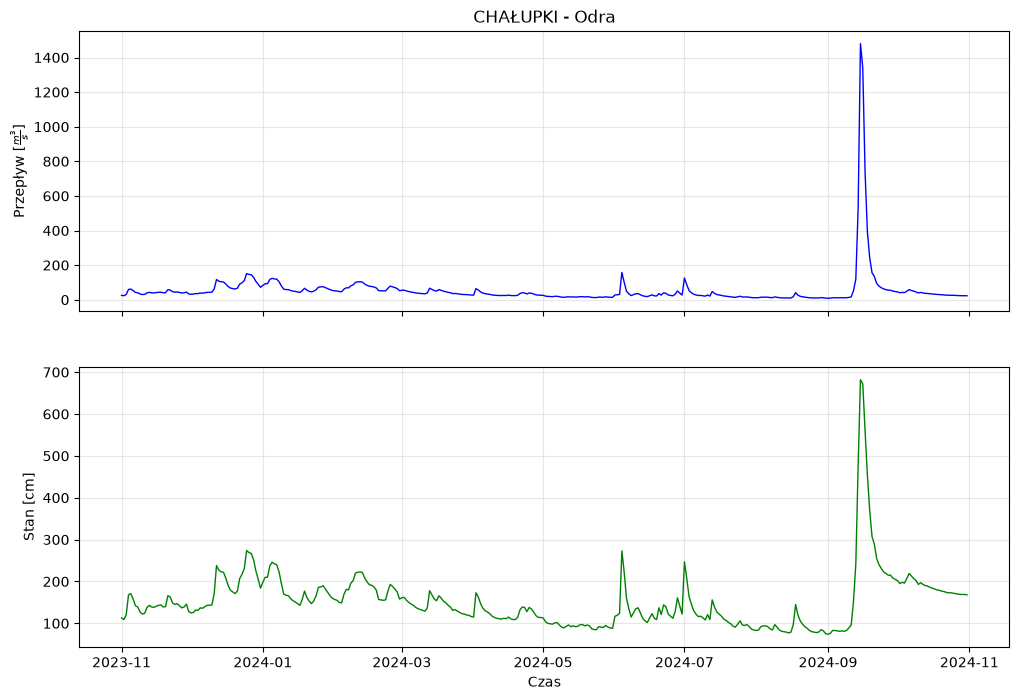

In [19]:
stacja = "CHAŁUPKI"


stacja_df = codz_2024[codz_2024.stacja == stacja].sort_values("data").set_index("data")

fig, (ax1, ax2) = plt.subplots(2, sharex=True, figsize=(12,8))

ax1.plot(stacja_df.przeplyw, linewidth=1, color="blue")
ax1.set_ylabel(r"Przepływ [$\frac{m^3}{s}$]")
ax1.set_title(f"{stacja} - {stacja_df['rzeka'].iloc[0]}")
ax1.grid(True, alpha=0.3)

ax2.plot(stacja_df.stan, linewidth=1, color="green")
ax2.set_ylabel("Stan [cm]")
ax2.set_xlabel("Czas")
ax2.grid(True, alpha=0.3)

plt.show()